LINK TO COLAB WHERE I TESTED GPU USAGE: https://colab.research.google.com/drive/1iAU_Tm2MusmsOUn5aODhr64kI76wWNMg?usp=sharing

# IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy


from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_curve, auc, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
#from scikitplot.metrics import plot_roc

from collections import defaultdict
from collections import Counter
from sklearn.preprocessing import StandardScaler, MinMaxScaler,RobustScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor


# LOAD CSV

In [2]:
pd.set_option('display.max_colwidth', None)  # Show full content in columns
pd.set_option('display.max_rows', None)

In [3]:
df = pd.read_csv("dataset/train_post_outlier.csv")

# FAST CHECK AND PROCESS

In [4]:
cols_to_drop = ["Unnamed: 0", 'countryOfOrigin', 'genres', 'soundMixes', 'continent', 'filtered_genres', 'filtered_soundMixes']
df = df.drop(columns = cols_to_drop)

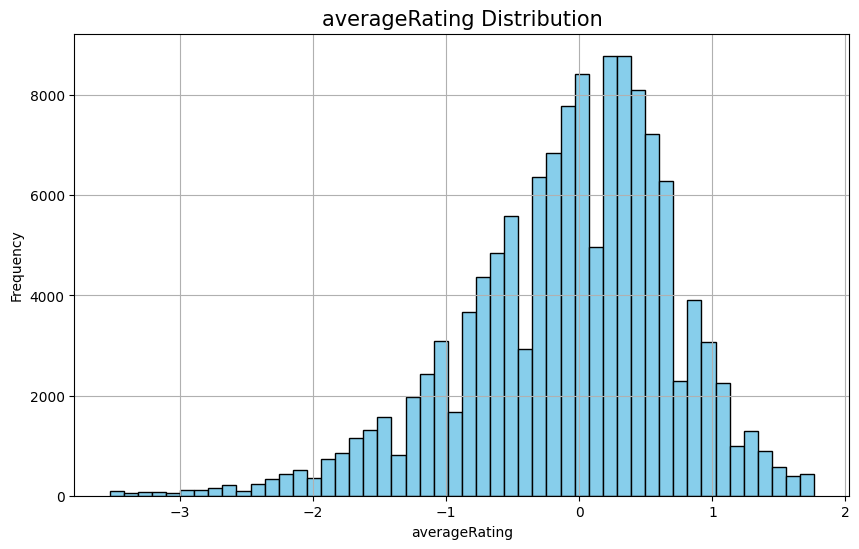

In [5]:
plt.figure(figsize=(10, 6))
plt.hist(df['averageRating'], bins=50, color='skyblue', edgecolor='black')
plt.title('averageRating Distribution', size=15)
plt.xlabel('averageRating')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# SPLIT

In [ ]:
target_name = ''
target_name = 'averageRating'
df = df.drop(columns="rating_class")

In [7]:
attributes = [col for col in df.columns if col != target_name]

X = df[attributes].values
y = np.array(df[target_name]) 

X.shape, y.shape

((129663, 61), (129663,))

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((103730, 61), (25933, 61), (103730,), (25933,))

In [9]:
# baseline
y_baseline = np.full_like(y_test, np.mean(y_train)) # Calcolo della media della variabile target
mse_baseline = mean_squared_error(y_test, y_baseline)
print("MSE del modello baseline:", mse_baseline)
print('R² del modello baseline:', r2_score(y_test, y_baseline))
print("MAE del modello baseline:", mean_absolute_error(y_test, y_baseline))

MSE del modello baseline: 0.6193565353493156
R² del modello baseline: -5.456640859602402e-06
MAE del modello baseline: 0.6149547847622774


# SUPPORT VECTOR REGRESSOR

In [10]:
param_grid = {
    'kernel': ['poly', 'rbf', 'sigmoid'],
    'C': [0.01, 1, 10, 100],
    'epsilon': [0.01, 0.1, 1, 10]
}

In [ ]:


grid_search = RandomizedSearchCV(
    SVR(),
    param_distributions=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_iter=10,
    random_state=42,
    n_jobs=-1,
    verbose=2  # Add this
)
grid_search.fit(X_train, y_train)
print("Migliori parametri: ", grid_search.best_params_, grid_search.best_score_) 

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KeyboardInterrupt: 

In [ ]:
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV

grid_search = HalvingRandomSearchCV(
    SVR(),
    param_distributions=param_grid,
    factor=2,
    resource='n_samples',
    max_resources='auto',
    scoring='neg_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=2
)
grid_search.fit(X_train, y_train)

print("Fit completato, sto per stampare i parametri migliori...")

print("Migliori parametri: ", grid_search.best_params_, grid_search.best_score_) 

n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 15
min_resources_: 6
max_resources_: 103730
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 48
n_resources: 6
Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV] END ..................C=0.01, epsilon=0.01, kernel=poly; total time=   0.0s
[CV] END ..................C=0.01, epsilon=0.01, kernel=poly; total time=   0.0s
[CV] END ..................C=0.01, epsilon=0.01, kernel=poly; total time=   0.0s
[CV] END ...................C=0.01, epsilon=0.01, kernel=rbf; total time=   0.0s
[CV] END ...................C=0.01, epsilon=0.01, kernel=rbf; total time=   0.0s
[CV] END ...................C=0.01, epsilon=0.01, kernel=rbf; total time=   0.0s
[CV] END ...............C=0.01, epsilon=0.01, kernel=sigmoid; total time=   0.0s
[CV] END ...............C=0.01, epsilon=0.01, kernel=sigmoid; total time=   0.0s
[CV] END ...............C=0.01, epsilon=0.01, kernel=sigmoid; total time=   0.0s
[CV] END .

/Users/daviderizzello/Documents/UNIPI/Data_Mining/DataMining2/env/lib/python3.11/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 48 is smaller than n_iter=17288. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END ..................C=100, epsilon=10, kernel=sigmoid; total time=   0.0s
----------
iter: 1
n_candidates: 24
n_resources: 12
Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END .................C=10, epsilon=0.01, kernel=sigmoid; total time=   0.0s
[CV] END .................C=10, epsilon=0.01, kernel=sigmoid; total time=   0.0s
[CV] END .................C=10, epsilon=0.01, kernel=sigmoid; total time=   0.0s
[CV] END ......................C=10, epsilon=0.1, kernel=rbf; total time=   0.0s
[CV] END ......................C=10, epsilon=0.1, kernel=rbf; total time=   0.0s
[CV] END ......................C=10, epsilon=0.1, kernel=rbf; total time=   0.0s
[CV] END .....................C=100, epsilon=0.1, kernel=rbf; total time=   0.0s
[CV] END .....................C=100, epsilon=0.1, kernel=rbf; total time=   0.0s
[CV] END .....................C=100, epsilon=0.1, kernel=rbf; total time=   0.0s
[CV] END ....................C=100, epsilon=0.01, kernel=rbf; total time=   0

In [ ]:
best_SVR_model = grid_search.best_estimator_

y_train_pred = best_SVR_model.predict(X_train)
y_test_pred = best_SVR_model.predict(X_test)

print('Performance sul training set:')
print('R²:', r2_score(y_train, y_train_pred))
print('MSE:', mean_squared_error(y_train, y_train_pred))
print('MAE', mean_absolute_error(y_train, y_train_pred))
print()

print('Performance sul test set:')
print('R²:', r2_score(y_test, y_test_pred))
print('MSE:', mean_squared_error(y_test, y_test_pred))
print('MAE', mean_absolute_error(y_test, y_test_pred))

Performance sul training set:
R²: 0.5453630289273672
MSE: 0.4545754197975902
MAE 0.5338855607790172

Performance sul test set:
R²: 0.5444017343628835
MSE: 0.4558311969568244
MAE 0.5341251004137887


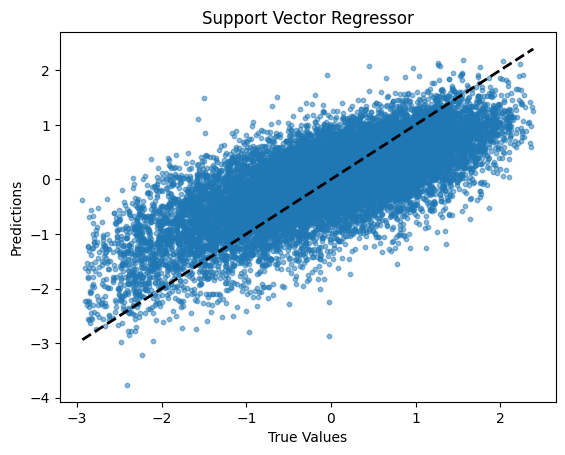

In [31]:
plt.scatter(y_test, y_test_pred, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("Support Vector Regressor")
plt.show()

# GRADIENT BOOSTING REGRESSOR

In [ ]:
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [200, 500, 800],    
    'min_samples_split': [2,5]
} 

# cross-validation
grid_search = RandomizedSearchCV(estimator= GradientBoostingRegressor(), param_distributions= param_grid, n_iter=10, cv=5, scoring='neg_mean_squared_error',random_state=42, n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Migliori parametri: ", grid_search.best_params_, grid_search.best_score_) 


KeyboardInterrupt: 

In [ ]:

best_GBR_model = grid_search.best_estimator_

y_train_pred = best_GBR_model.predict(X_train)
y_test_pred = best_GBR_model.predict(X_test)

print('Performance sul training set:')
print('R²:', r2_score(y_train, y_train_pred))
print('MSE:', mean_squared_error(y_train, y_train_pred))
print()

print('Performance sul test set:')
print('R²:', r2_score(y_test, y_test_pred))
print('MSE:', mean_squared_error(y_test, y_test_pred))
print('MAE', mean_absolute_error(y_test, y_test_pred))

Performance sul training set:
R²: 0.37324509116431837
MSE: 0.39600434458301326

Performance sul test set:
R²: 0.34788380765345395
MSE: 0.4038902216530583
MAE 0.4702171343373998


param_grid = {
    'n_estimators': [50, 100, 500],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_samples_split': [2,5]
} 


Performance sul training set:
R²: 0.37324509116431837
MSE: 0.39600434458301326

Performance sul test set:
R²: 0.34788380765345395
MSE: 0.4038902216530583
MAE 0.4702171343373998


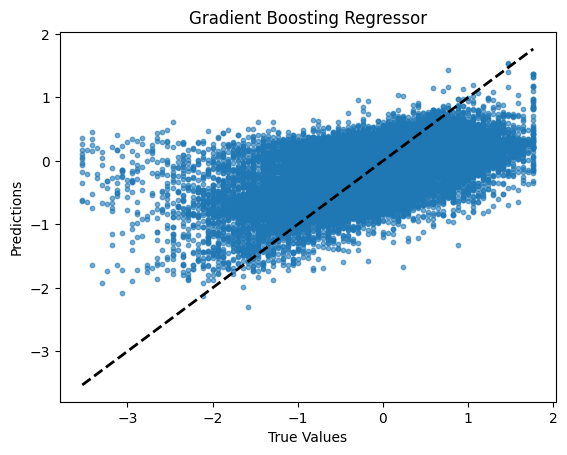

In [13]:
plt.scatter(y_test, y_test_pred, alpha=0.6, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("Gradient Boosting Regressor")
plt.show()

In [14]:
importances = best_GBR_model.feature_importances_

feature_importance = list(zip(attributes, importances))

feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)

for feature, importance in feature_importance:
    print(f"{feature}: {importance}")

titleType_tvEpisode: 0.3093964028549562
release_decade: 0.1210572182964217
numVotes: 0.07494162930167117
genre_Documentary: 0.0696200712453838
runtimeMinutes: 0.06581896130843007
titleType_movie: 0.06546485054048712
num_genres: 0.025004708386508267
total_multimedia: 0.019930034459917454
totalCredits: 0.019288841096978957
genre_Drama: 0.017280514729069694
castNumber: 0.016732974591713638
userReviewsTotal: 0.01643522672664801
companiesNumber: 0.015951592816190154
externalLinks: 0.015481929376143379
writerCredits: 0.00962928751475745
continent_North America: 0.009571693630609538
awardWins: 0.00889214057535741
award_ratio: 0.008239013059594347
numRegions: 0.007640689084007236
directorsCredits: 0.007590883708239638
continent_Europe: 0.007585480303512756
title_length: 0.007225697264403551
canHaveEpisodes: 0.006562132225621398
titleType_video: 0.005225953952550852
genre_Action: 0.004867444129905183
awardNominationsExcludeWins: 0.004763478422743212
num_regions: 0.004699890352756285
genre_Adven

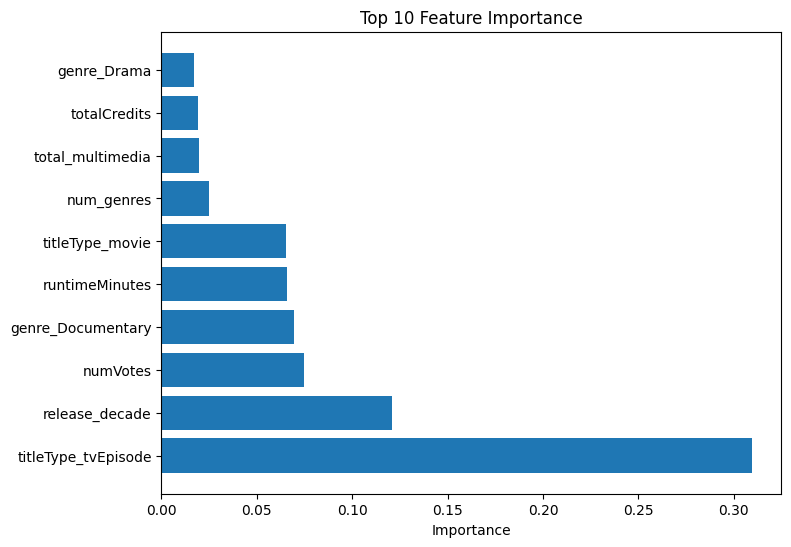

In [15]:
features, importances = zip(*feature_importance[:10])

plt.figure(figsize=(8, 6))
plt.barh(range(len(features)), importances, align='center')
plt.yticks(range(len(features)), features)
plt.xlabel('Importance')
plt.title('Top 10 Feature Importance')
plt.show()

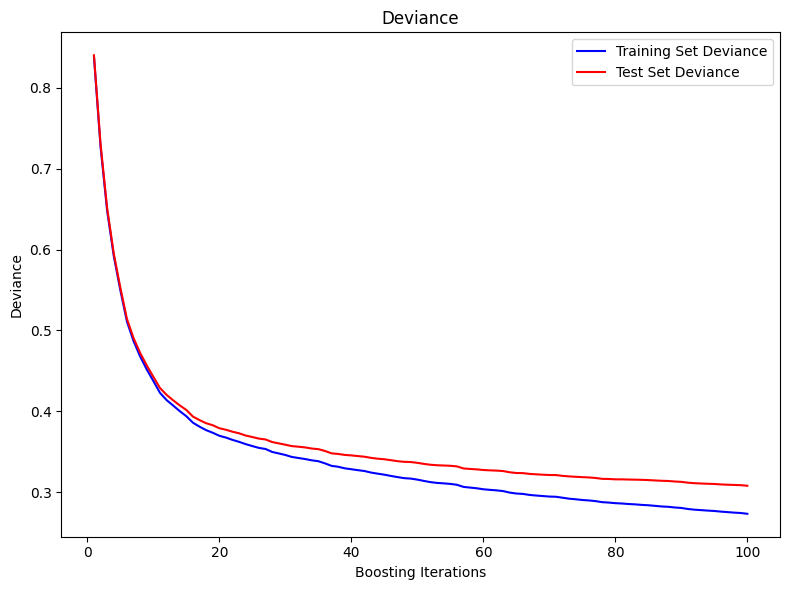

In [38]:
params = grid_search.best_params_

test_score = np.zeros((params["n_estimators"],), dtype=np.float64)
for i, y_pred in enumerate(best_GBR_model.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred)

fig = plt.figure(figsize=(8, 6))
plt.subplot(1, 1, 1)
plt.title("Deviance")
plt.plot(
    np.arange(params["n_estimators"]) + 1,
    best_GBR_model.train_score_,
    "b-",
    label="Training Set Deviance",
)
plt.plot(
    np.arange(params["n_estimators"]) + 1, test_score, "r-", label="Test Set Deviance"
)
plt.legend(loc="upper right")
plt.xlabel("Boosting Iterations")
plt.ylabel("Deviance")
fig.tight_layout()
plt.show()

# RANDOM FOREST REGRESSOR

In [14]:

rf_regressor = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],  
    'max_features': ['log2', 'sqrt'],  
}

random_search = RandomizedSearchCV(
    estimator=rf_regressor,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1  
)

random_search.fit(X_train, y_train)

print("Best parameters found:")
print(random_search.best_params_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found:
{'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': True}


In [15]:
best_rf_model = random_search.best_estimator_

y_train_pred = best_rf_model.predict(X_train)
y_test_pred = best_rf_model.predict(X_test)


print('Performance sul training set:')
print('R²:', r2_score(y_train, y_train_pred))
print('MSE:', mean_squared_error(y_train, y_train_pred))
print()

print('Performance sul test set:')
print('R²:', r2_score(y_test, y_test_pred))
print('MSE:', mean_squared_error(y_test, y_test_pred))
print('MAE', mean_absolute_error(y_test, y_test_pred))

Performance sul training set:
R²: 0.5777159964956111
MSE: 0.2668129083285547

Performance sul test set:
R²: 0.3726210780833058
MSE: 0.388569115147402
MAE 0.4601823122189953


In [16]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))


Train R²: 0.9190153993402028
Test R²: 0.42401981326254523
Test MAE: 0.4316512023129295


In [17]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [20, 30, None],  # None = profondità illimitata
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', None],  # più feature considerate a split
    'bootstrap': [True]  # evita overfitting duro
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,  # aumenta a 20 per esplorare bene lo spazio
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

print("✅ Best parameters:")
print(random_search.best_params_)
print("Best MSE (negativo):", random_search.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time= 2.2min
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time= 2.2min
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time= 2.2min
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time= 2.2min
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time= 2.2min
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=500; total time= 2.3min
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimat

/Users/daviderizzello/Documents/UNIPI/Data_Mining/DataMining2/env/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time= 2.1min
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time= 2.1min
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=500; total time= 2.4min
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time= 1.6min
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time= 1.7min
[CV] END bootstrap=True, max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time= 1.7min
[CV] END bootstrap=True, max_depth=None, max_features=None, min_samples_leaf=4, min_samples_split=5, n_estimators=500; total time=13.9min
[CV] END bootstrap=True, max_depth=None, max

In [18]:
best_rf_model = random_search.best_estimator_

y_train_pred = best_rf_model.predict(X_train)
y_test_pred = best_rf_model.predict(X_test)


print('Performance sul training set:')
print('R²:', r2_score(y_train, y_train_pred))
print('MSE:', mean_squared_error(y_train, y_train_pred))
print()

print('Performance sul test set:')
print('R²:', r2_score(y_test, y_test_pred))
print('MSE:', mean_squared_error(y_test, y_test_pred))
print('MAE', mean_absolute_error(y_test, y_test_pred))

Performance sul training set:
R²: 0.9195193954361477
MSE: 0.050850290301130516

Performance sul test set:
R²: 0.42461867866641045
MSE: 0.35636423713422594
MAE 0.4337464640849778


Performance sul training set:
R²: 0.9788279804297915
MSE: 2.562199232463344

Performance sul test set:
R²: 0.7484844204817133
MSE: 31.881634321770324
MAE 1.396946440789807

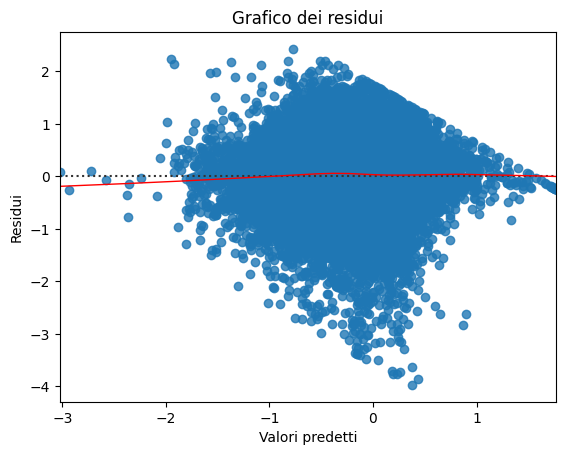

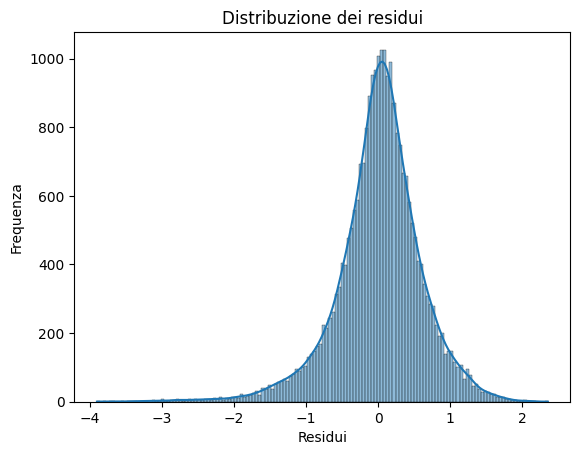

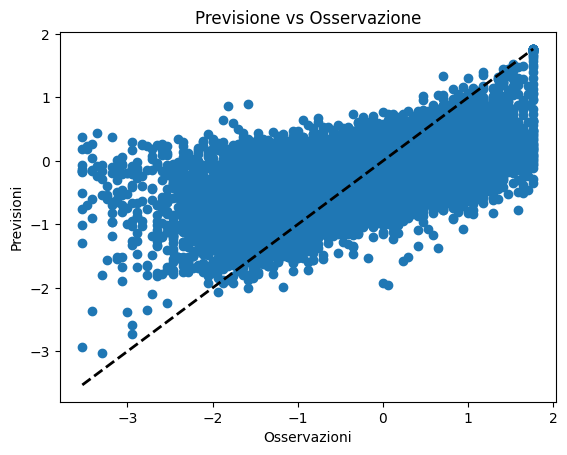

In [19]:
residuals = y_test - y_test_pred

sns.residplot(x= y_test_pred, y= residuals, lowess=True, line_kws={'color': 'red', 'lw': 1})
plt.xlabel('Valori predetti')
plt.ylabel('Residui')
plt.title('Grafico dei residui')
plt.show()

sns.histplot(residuals, kde=True)
plt.xlabel('Residui')
plt.ylabel('Frequenza')
plt.title('Distribuzione dei residui')
plt.show()

plt.scatter(y_test, y_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Osservazioni')
plt.ylabel('Previsioni')
plt.title('Previsione vs Osservazione')
plt.show()


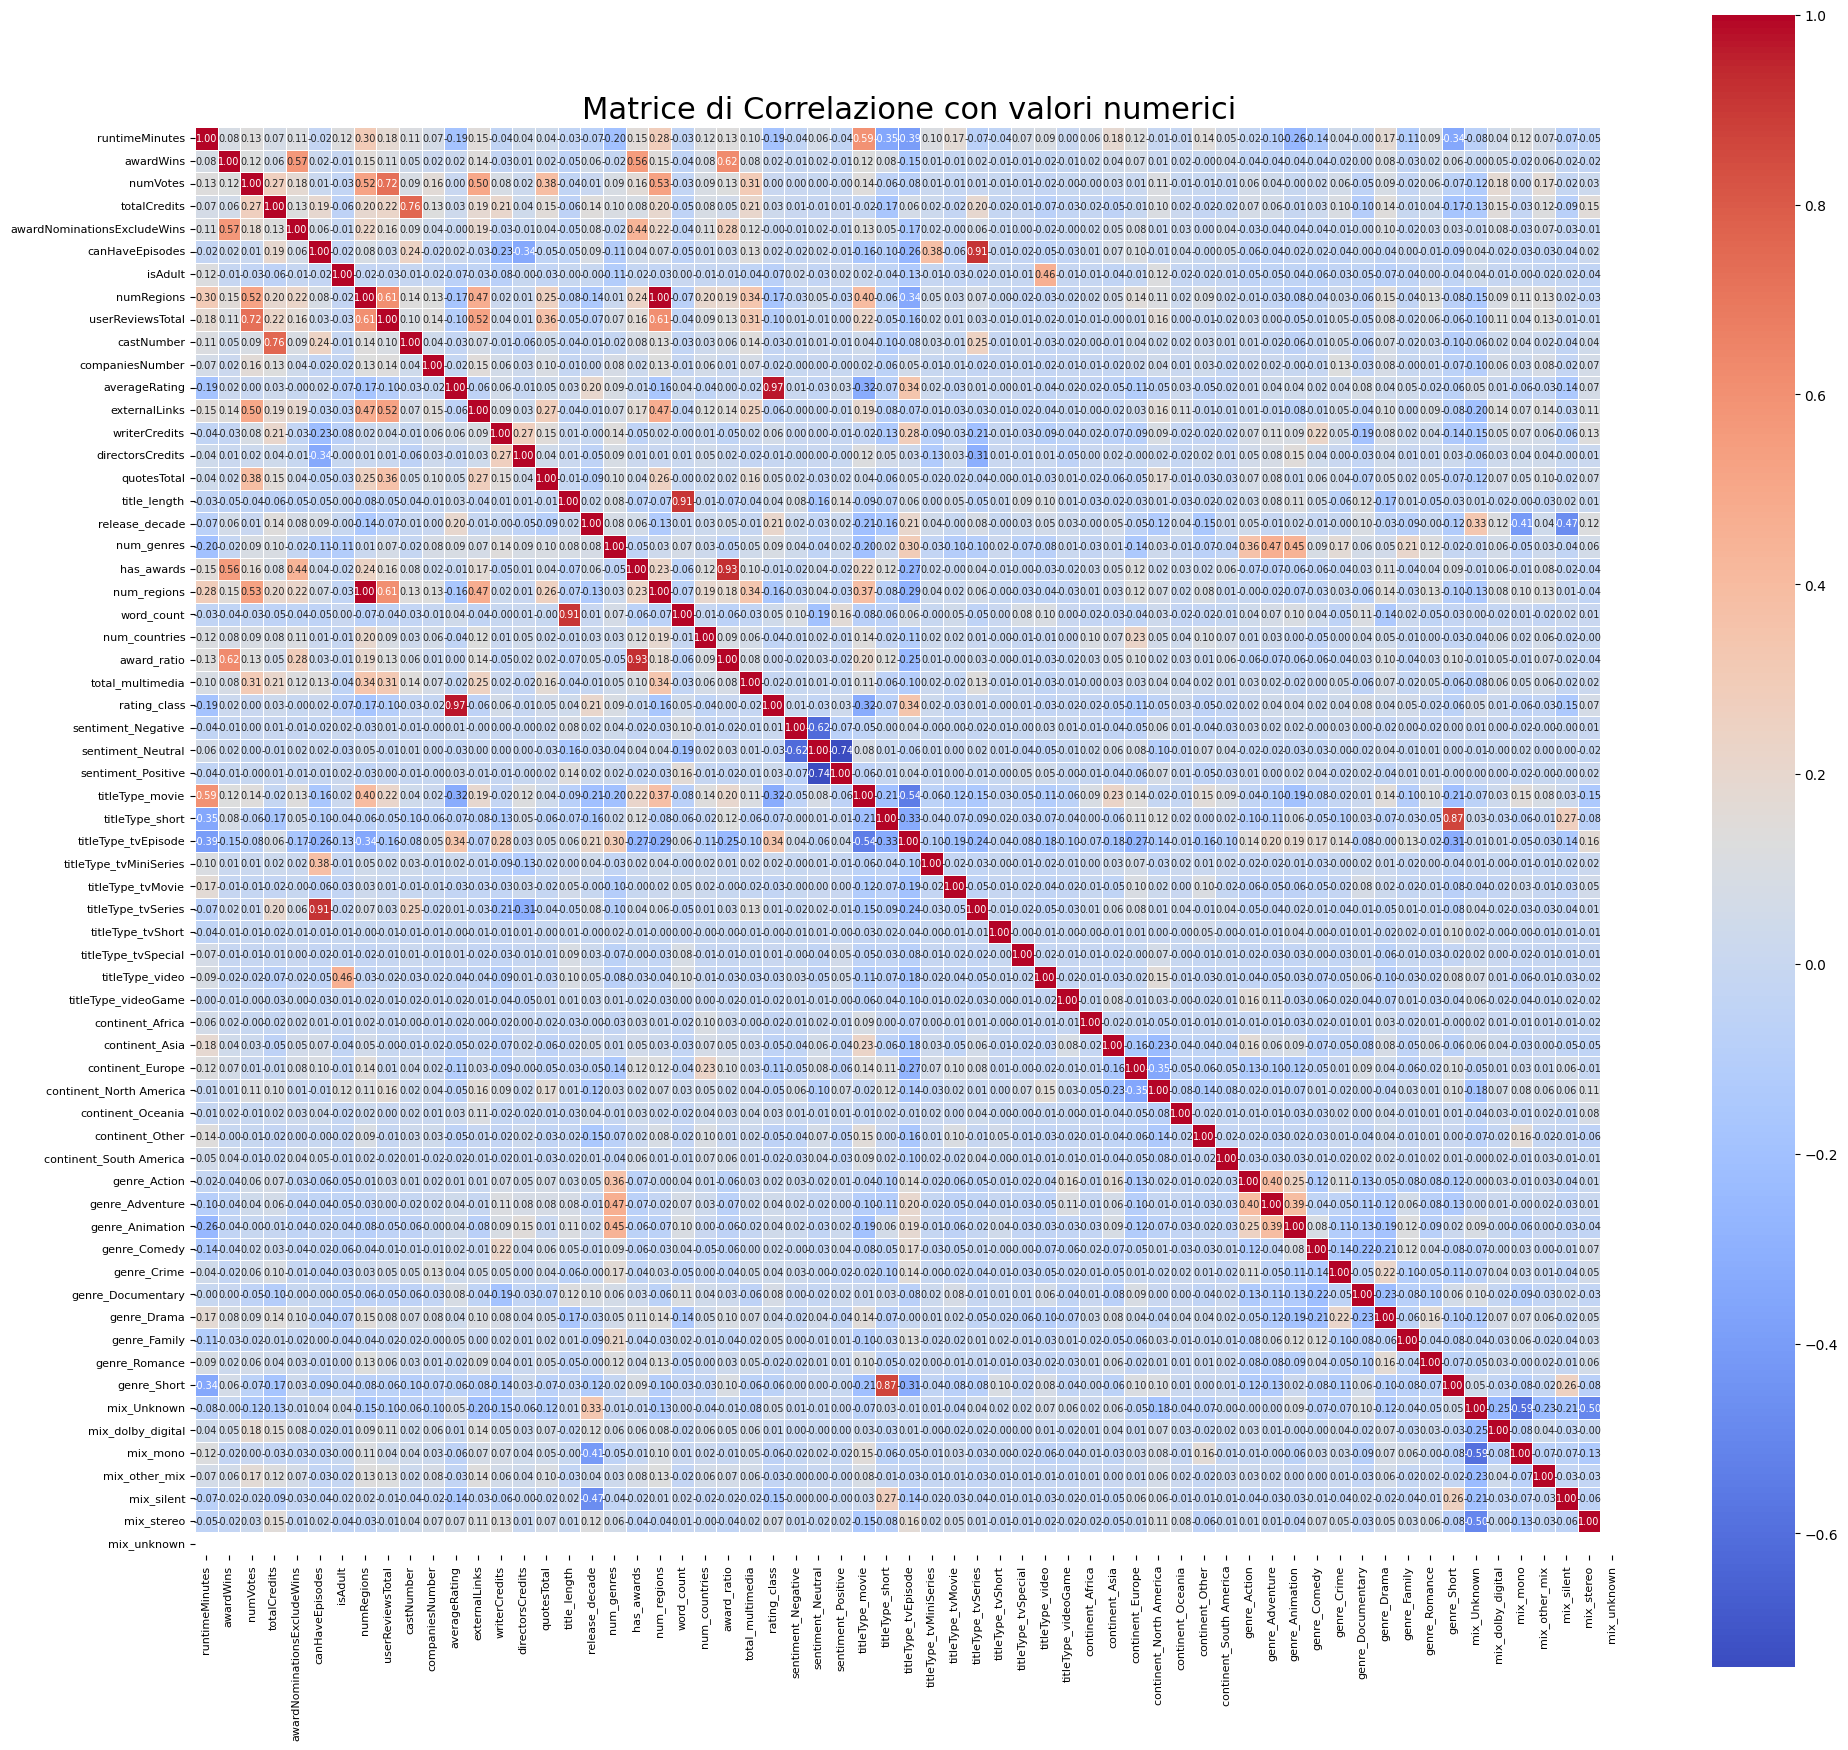

In [ ]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20, 18))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, linewidths=.5, annot_kws={"size":7})

plt.title('Matrice di Correlazione con valori numerici', fontsize=22)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


RISULTATI